# What can be done next?
- permutation of bases

- change number of features deleted

- change model

- change metric

- extract other homological invariant

In [709]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from gtda.diagrams import PairwiseDistance
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'DejaVu Sans Mono'


def tda_dist(ser_1, ser_2, metric='bottleneck'):
    pdist = PairwiseDistance(metric=metric)
    index = ser_1.index
    ser_1 = ser_1.values.reshape(ser_1.shape[0], 1, -1, 2)
    ser_1 = np.pad(ser_1, pad_width=((0, 0), (0, 0), (0, 0), (0, 1)), constant_values=1)
    ser_2 = ser_2.values.reshape(ser_2.shape[0], 1, -1, 2)
    ser_2 = np.pad(ser_2, pad_width=((0, 0), (0, 0), (0, 0), (0, 1)), constant_values=1)
    result = [pdist.fit(dgm_1).transform(dgm_2)[0, 0] for dgm_1, dgm_2 in zip(ser_1, ser_2)]
    return pd.Series(result, index=index)

In [561]:
from scipy.stats import pearsonr

# Performance before and after

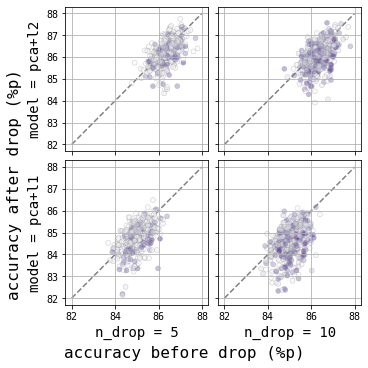

In [802]:
df_result = pd.read_csv('../output/20230517_exp_log_500.csv')
ag_only = True
models = ['pca+l2', 'pca+l1', 'pca+DT', 'CatNB']
n_drops = [5, 10, 15, 20]
models = models[:2]; n_drops = n_drops[:2]

nrows = len(models); ncols = len(n_drops)
fig, axs = plt.subplots(
    nrows=nrows, ncols=ncols, sharex=True, sharey=True, 
    figsize=(2.5*nrows, 2.5*ncols), layout='constrained'
)
for i, model_name in enumerate(models):
    for j, n_drop in enumerate(n_drops):
        current_mask = (df_result['A&G_only'] == ag_only) & (df_result['n_drop'] == n_drop) & (df_result['model'] == model_name)
        grouper = df_result.loc[current_mask, 'split_id']
        df_current = df_result[current_mask]

        persistence_control = df_current.loc[:, 'birth_control_0':'death_control_9']
        persistence_modified = df_current.loc[:, 'birth_modified_0':'death_modified_9']
        dgm_dist = tda_dist(persistence_modified, persistence_control, metric='silhouette')
        acc_before = df_current['accuracy_control']
        acc_after = df_current['accuracy_modified']

        corr_x = acc_before; corr_y = acc_after; color = dgm_dist
        corr_x = corr_x.groupby(grouper).agg('mean')
        corr_y = corr_y.groupby(grouper).agg('mean')
        color = color.groupby(grouper).agg('mean')

        ax = axs[i, j]
        ax.scatter(
            x=corr_x, y=corr_y, 
            s=25, alpha=0.4, c=color, 
            linewidths=0.5, edgecolors='grey',
            cmap='Purples'
        )
        ax.plot([82, 88], [82, 88], color='grey', linestyle='--', zorder=0)
        ax.grid()
        if i == nrows-1:
            ax.set_xlabel(f'n_drop = {n_drop}', fontsize=14)
        if j == 0:
            ax.set_ylabel(f'model = {model_name}', fontsize=14)
fig.supxlabel('accuracy before drop (%p)', fontsize=16)
fig.supylabel('accuracy after drop (%p)', fontsize=16)

plt.show(); plt.close()

# Change of shape vs. Change of performance

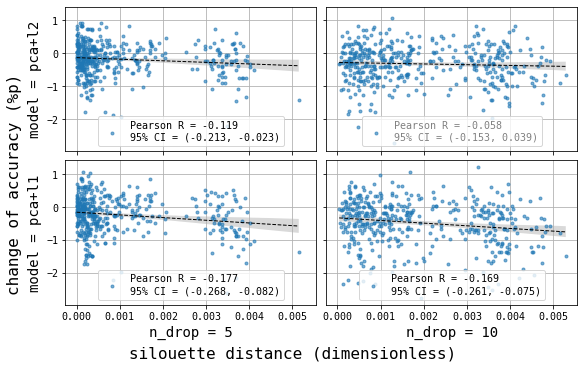

In [796]:
# df_result = pd.read_csv('../output/20230504_topology_vs_accuracy.csv')
df_result = pd.read_csv('../output/20230517_exp_log_500.csv')
models = ['pca+l2', 'pca+l1', 'pca+DT', 'CatNB']
n_drops = [5, 10, 15, 20]
models = models[:2]; n_drops = n_drops[:2]
ag_only = True

nrows = len(models); ncols = len(n_drops)
fig, axs = plt.subplots(
    nrows=nrows, ncols=ncols, sharex=True, sharey=True, 
    figsize=(4*nrows, 2.5*ncols), layout='constrained'
)
for i, model_name in enumerate(models):
    for j, n_drop in enumerate(n_drops):
        current_mask = (df_result['A&G_only'] == ag_only) & (df_result['n_drop'] == n_drop) & (df_result['model'] == model_name)
        grouper = df_result.loc[current_mask, 'split_id']
        df_current = df_result[current_mask]

        persistence_control = df_current.loc[:, 'birth_control_0':'death_control_9']
        persistence_modified = df_current.loc[:, 'birth_modified_0':'death_modified_9']

        # dgm_dist = df_result.loc[current_mask, 'birth_modified_0'] - df_result.loc[current_mask, 'birth_control_0']
        dgm_dist = tda_dist(persistence_modified, persistence_control, metric='silhouette')
        acc_change = df_current['accuracy_modified'] - df_current['accuracy_control']

        corr_x = dgm_dist; corr_y = acc_change
        corr_x = corr_x.groupby(grouper).agg('mean')
        corr_y = corr_y.groupby(grouper).agg('mean')

        corr_result = pearsonr(corr_x, corr_y, alternative='two-sided')
        r_val = corr_result.statistic
        p_val = corr_result.pvalue * 2
        conf_interval = corr_result.confidence_interval().low, corr_result.confidence_interval().high
        is_significant = conf_interval[1] < 0

        ax = axs[i, j]
        sns.regplot(
            x=corr_x, y=corr_y,
            seed=42,
            label=f'Pearson R = {r_val:.3f}\n95% CI = ({conf_interval[0]:.3f}, {conf_interval[1]:.3f})',
            color='C0',
            scatter_kws={
                's': 9,
                'alpha': 0.6,
                'zorder': 3
            },
            line_kws={
                'linestyle': '--',
                'linewidth': 1,
                'color': 'black',
                'zorder': 4,
            },
            ax=ax,
        )
        ax.grid()
        ax.legend(loc='lower center', labelcolor='black' if is_significant else 'grey')
        if i == nrows-1:
            ax.set_xlabel(f'n_drop = {n_drop}', fontsize=14)
        if j == 0:
            ax.set_ylabel(f'model = {model_name}', fontsize=14)
fig.supxlabel('silouette distance (dimensionless)', fontsize=16)
fig.supylabel('change of accuracy (%p)', fontsize=16)

plt.show(); plt.close()